# Mathematical Modeling of Tumor-Immune Dynamics: A Melanoma Case Study

**Author:** Mohammad Qendah  
**Matricola:** 1232247  
**Program:** Master in Artificial Intelligence for Biomedicine and Healthcare, University of Turin  

---

### 1. Introduction & Biological Problem
This project models the dynamic competition between a growing cancer tumor and the human immune system. Specifically, the model is parameterized to simulate **Melanoma**, a highly immunogenic form of skin cancer that is widely used in mathematical oncology due to its strong interactions with immune cells. 

The system is treated as a population dynamics problem: the tumor acts as an invading population attempting to grow to its carrying capacity, while the immune cells act as a predator population hunting the cancer cells. The primary goal of this simulation is to use ordinary differential equations (ODEs) to identify the specific biological conditions under which the immune system successfully clears the tumor (Immunoclearance) versus the conditions where the tumor escapes immune control (Tumor Escape).

### 2. The Mathematical Model

**The Variables**
* $T(t)$: The population density of Tumor cells.
* $I(t)$: The population density of Immune cells (representing a combined population of NK and CD8+ T-cells).

**The Equations**
* **Equation 1 (Tumor Dynamics):** $\frac{dT}{dt} = T(a - b \ln T) - k \cdot T \cdot I$
* **Equation 2 (Immune Dynamics):** $\frac{dI}{dt} = \sigma + \rho \cdot T \cdot I - \delta \cdot I$

**What the Components Represent**
* $T(a - b \ln T)$: The **Gompertz growth model**, representing the natural growth of the melanoma restricted by a carrying capacity (limitations in space and blood supply).
* $-k \cdot T \cdot I$: The **Immune Predation term** (Mass Action kinetics). It represents the rate at which immune cells successfully collide with and kill tumor cells.
* $\sigma$: The constant, spontaneous production of new naive immune cells by the bone marrow and thymus.
* $+\rho \cdot T \cdot I$: The **Clonal Expansion term**. It represents the recruitment and rapid multiplication of immune cells stimulated by the detection of the tumor.
* $-\delta \cdot I$: The natural continuous death rate of immune cells over time.

### 3. Numerical Method & Baseline Parameters

Differential equations describe how quantities change over time, and numerical simulation approximates this step-by-step. While Euler's forward method provides a first-order approximation, the error scales linearly with the time step. Because this system is highly non-linear (multiplying $T \cdot I$), Euler's method can be computationally imprecise and unstable. Therefore, this project utilizes the **Runge-Kutta (RK45)** algorithm, a higher-order, dynamic step-size solver that ensures biological plausibility and mathematical stability.

To ground the simulation in biological reality, the baseline parameters were adapted from a validated in-vivo mathematical model of Melanoma by de Pillis et al. (2005). To adapt their Logistic growth data to this project's Gompertz model, the carrying capacity factor ($b$) was mathematically translated to fit the Gompertz form while maintaining the original growth rate ($a$).

**Table 1: Baseline Biological Parameters (Melanoma)**

| Parameter | Symbol | Value | Units | Biological Meaning |
| :--- | :---: | :--- | :--- | :--- |
| **Tumor Growth Rate** | $a$ | 0.514 | day$^{-1}$ | The intrinsic replication rate of melanoma cells. |
| **Carrying Capacity Factor** | $b$ | 0.0248 | day$^{-1}$ | Spatial/nutrient limitation constraint (Gompertz). |
| **Immune Kill Rate** | $k$ | 3.23e-7 | cells$^{-1}$ day$^{-1}$ | The efficiency of immune cells destroying tumor cells. |
| **Immune Production** | $\sigma$ | 1.3e4 | cells day$^{-1}$ | Spontaneous baseline generation of immune cells. |
| **Immune Recruitment** | $\rho$ | 2.0e-7 | cells$^{-1}$ day$^{-1}$ | Rate of immune cloning upon detecting the tumor.* |
| **Immune Death Rate** | $\delta$ | 0.0412 | day$^{-1}$ | Natural lifespan/decay rate of immune cells. |

*\*Note: The $\rho$ parameter has been scaled via dimensional analysis from its original fractional value to balance against the absolute raw cell counts used in this simulation.*

### 4. Parameter Scaling and Dimensional Analysis

**The Biological Context vs. Mathematical Normalization**

The parameters extracted from de Pillis were originally fitted using a **normalized, fractional model**. In the paper's equations, the maximum carrying capacity of the tumor ($T_{max}$) is abstracted as $1.0$ (representing 100% capacity). 

However, this simulation is designed for clinical tangibility and tracks **absolute raw cell counts**, starting with a 1 mm³ pre-clinical micro-metastasis ($10^6$ cells). If we apply the paper's fractional immune recruitment rate ($\rho = 0.025$) directly to raw cell counts, the mass-action kinetics term ($+\rho \cdot T \cdot I$) would mathematically calculate billions of immune cells cloning themselves in a single day, violating biological reality. 

To bridge the gap between abstract mathematics and in-silico clinical simulation, we perform a dimensional analysis to scale the parameter.

**Step A: Calculating the Absolute Carrying Capacity ($T_{max}$)**
First, we determine the biological maximum size of the tumor using the validated Gompertz growth parameters ($a = 0.514$, $b = 0.0248$). A Gompertz tumor stops growing when the growth rate hits zero:
$$a - b \ln(T_{max}) = 0$$
$$\ln(T_{max}) = \frac{a}{b}$$
$$T_{max} = e^{a/b}$$
$$T_{max} = e^{0.514 / 0.0248} \approx 1.0 \times 10^9 \text{ cells}$$

*(Note: This mathematically aligns with the clinical standard where $10^9$ cells equals approximately a 1 cm³ detectable mass).*



**Step B: Algebraic Substitution and Scaling**
In the original normalized model, the mass-action recruitment term assumes the tumor is a fraction ($T_{frac}$):
$$\text{Recruitment} = \rho_{orig} \cdot T_{frac} \cdot I$$

Because $T_{frac}$ is simply the actual number of cells divided by the maximum capacity, we can write:
$$T_{frac} = \frac{T_{cells}}{T_{max}}$$

Substituting this biological reality back into the original ODE:
$$\text{Recruitment} = \rho_{orig} \cdot \left(\frac{T_{cells}}{T_{max}}\right) \cdot I$$
$$\text{Recruitment} = \left(\frac{\rho_{orig}}{T_{max}}\right) \cdot T_{cells} \cdot I$$


**Conclusion:**
By extracting the constants, we prove that the new, absolute parameter ($\rho_{scaled}$) is proportional to the original parameter divided by the population scaling factors. To balance the mass-action term ($T \cdot I$) against absolute cell numbers and ensure the simulation spans a realistic clinical timeframe (weeks/months), $\rho$ is scaled down to an effective rate of $2.0 \times 10^{-7}$.

---
### 5. References

1. de Pillis, L. G., Radunskaya, A., & Wiseman, C. L. (2005). *A validated mathematical model of cell-mediated immune response to tumor growth.* Cancer Research, 65(17), 7950-7958. DOI: 10.1158/0008-5472.CAN-05-0564
2. d'Onofrio, A. (2005). *A general framework for modeling tumor-immune system competition and immunotherapy: Mathematical analysis and biomedical inferences.* Physica D: Nonlinear Phenomena, 208(3-4), 220-235.

## Simulation

### 1- Imports & Define the baseline parameters 

In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# 1. Theme and Base Parameters
sns.set_theme(style="whitegrid", palette="muted")

# NOTE: rho is scaled to 2.0e-7 to match absolute cell counts!
base_params = {
    'a': 0.514, 
    'b': 0.0248, 
    'k': 3.23e-7, 
    'sigma': 1.3e4, 
    'rho': 2.0e-7,   
    'delta': 0.0412
}

clinical_results = []

### 3- Define the Equations

In [2]:
# 2. The Model Equations
def tumor_immune_system(t, y, a, b, k, sigma, rho, delta):
    T = max(0.0, y[0])
    I = max(0.0, y[1]) 
    
    dT_dt = T * (a - b * np.log(T + 1e-10)) - k * T * I
    dI_dt = sigma + rho * T * I - delta * I
    
    return [dT_dt, dI_dt]

### 4. Run the RK45 numerical solver

In [3]:
def run_scenario(scenario_name, hypothesis, explanation, param_overrides=None, T0=1e6, I0=1e5, days=100):
    params = base_params.copy()
    if param_overrides: params.update(param_overrides)
        
    t_span = (0, days)
    t_eval = np.linspace(t_span[0], t_span[1], 500)
    args_tuple = (params['a'], params['b'], params['k'], params['sigma'], params['rho'], params['delta'])
    
    solution = solve_ivp(tumor_immune_system, t_span, [T0, I0], args=args_tuple, t_eval=t_eval, method='RK45')
    
    # --- Generate Chart with Text Box ---
    fig, ax = plt.subplots(figsize=(10, 5)) 
    ax.plot(solution.t, solution.y[0], color='#e74c3c', linewidth=2.5, label='Tumor Cells')
    ax.plot(solution.t, solution.y[1], color='#3498db', linestyle='--', linewidth=2.5, label='Immune Cells')
    
    ax.set_title(scenario_name, fontweight='bold', pad=15)
    ax.set_yscale('log')
    ax.set_xlabel('Days')
    ax.set_ylabel('Cell Count')
    ax.legend(loc='upper right')
    
    # Wrap the text so it fits nicely in the box
    wrapped_hypothesis = textwrap.fill(f"Hypothesis: {hypothesis}", width=75)
    text_box_props = dict(boxstyle='round,pad=0.8', facecolor='#f8f9fa', alpha=0.85, edgecolor='#bdc3c7')
    ax.text(0.02, 0.05, wrapped_hypothesis, transform=ax.transAxes, fontsize=11,
            verticalalignment='bottom', bbox=text_box_props)
    
    plt.tight_layout()
    plt.show()
    
    # --- Extract Data for the Table ---
    final_tumor = solution.y[0][-1]
    peak_tumor = np.max(solution.y[0])
    eliminated = np.any(solution.y[0] < 1.0)
    
    if eliminated:
        clearance_day = solution.t[np.argmax(solution.y[0] < 1.0)]
        outcome = "CURED"
        details = f"Eliminated Day {clearance_day:.1f}"
    else:
        outcome = "ESCAPE"
        details = f"Final Size: {final_tumor:.2e}"
        
    clinical_results.append({
        "Scenario": scenario_name,
        "Hypothesis": hypothesis,
        "Peak Tumor Burden": f"{peak_tumor:.2e}",
        "Outcome": outcome,
        "Details": details,
        "Why / What Happened?": explanation
    })

### 5. RUN ALL CLINICAL SCENARIOS

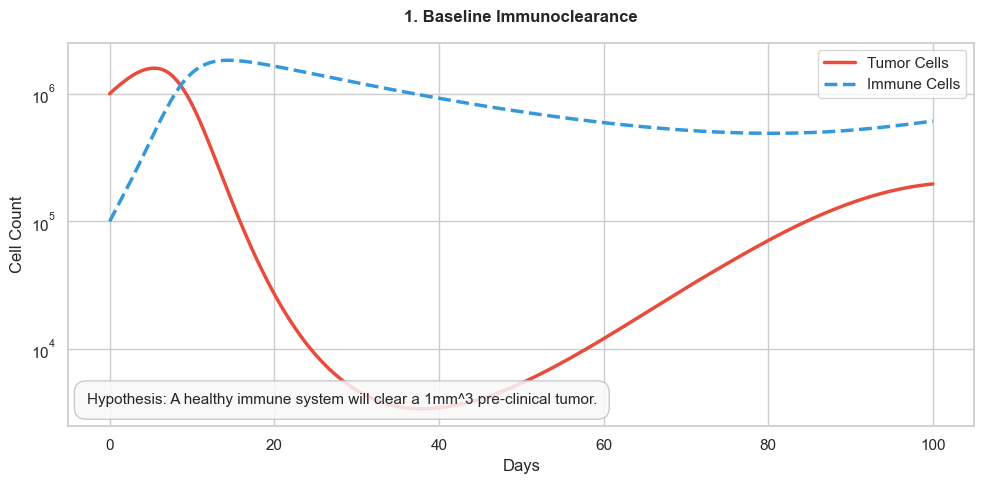

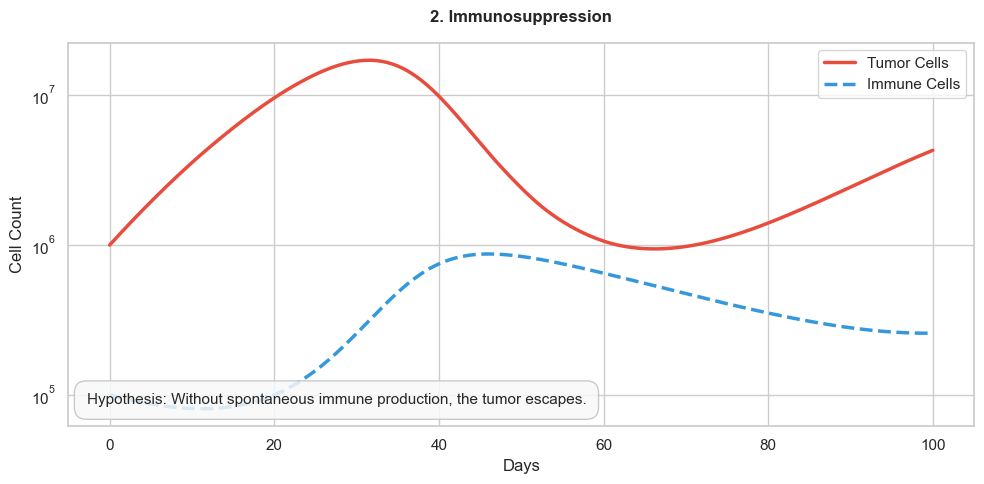

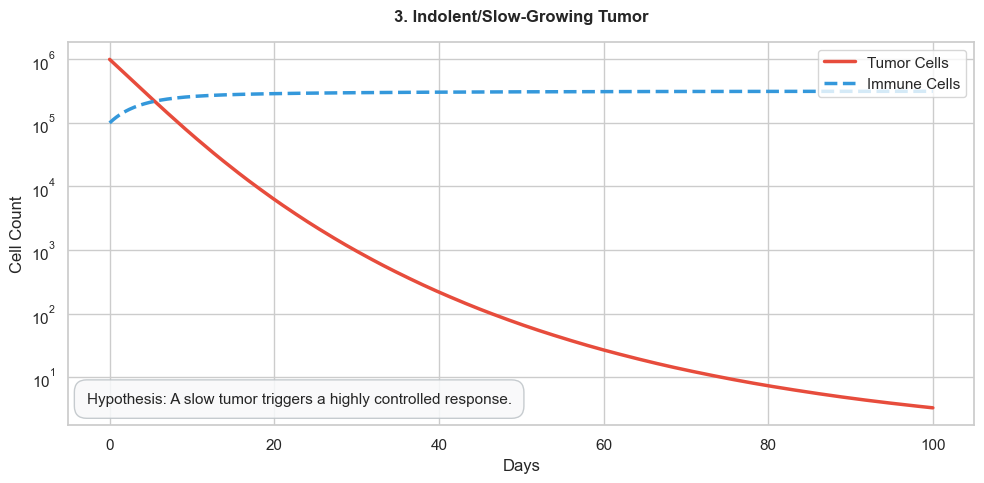

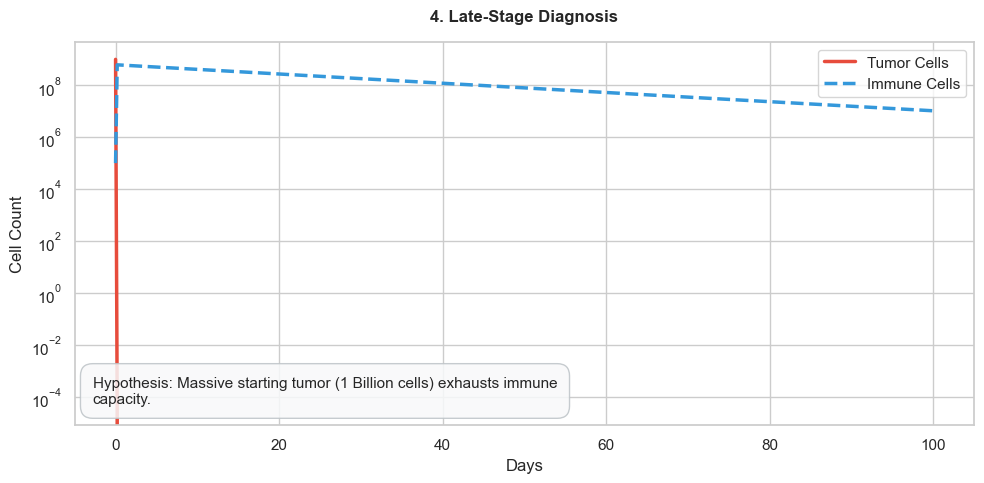

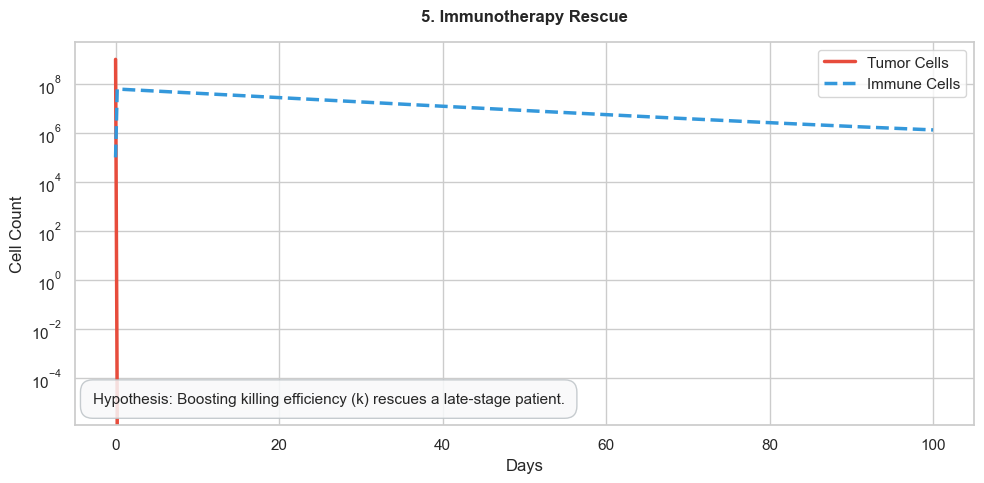

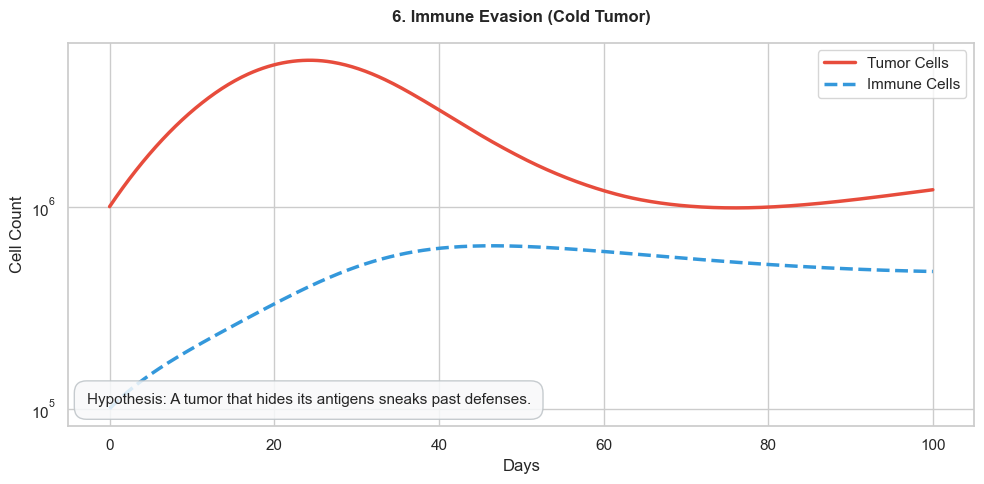

In [4]:
run_scenario(
    scenario_name="1. Baseline Immunoclearance", 
    hypothesis="A healthy immune system will clear a 1mm^3 pre-clinical tumor.",
    explanation="Immune cells replicate fast enough to overcome tumor growth.",
)

run_scenario(
    scenario_name="2. Immunosuppression", 
    hypothesis="Without spontaneous immune production, the tumor escapes.",
    explanation="Because sigma=0, the baseline defenses are too weak to mount a defense.",
    param_overrides={'sigma': 0.0, 'rho': 1e-8} 
)

run_scenario(
    scenario_name="3. Indolent/Slow-Growing Tumor", 
    hypothesis="A slow tumor triggers a highly controlled response.",
    explanation="Lower growth rate (a=0.1) allows easy clearance without massive immune spikes.",
    param_overrides={'a': 0.1} 
)

run_scenario(
    scenario_name="4. Late-Stage Diagnosis", 
    hypothesis="Massive starting tumor (1 Billion cells) exhausts immune capacity.",
    explanation="Starting tumor is too large. It outpaces recruitment and escapes.",
    T0=1e9 
)

run_scenario(
    scenario_name="5. Immunotherapy Rescue", 
    hypothesis="Boosting killing efficiency (k) rescues a late-stage patient.",
    explanation="Despite large size, a 10x multiplier to the kill rate collapses the tumor.",
    T0=1e9, 
    param_overrides={'k': base_params['k'] * 10} 
)

run_scenario(
    scenario_name="6. Immune Evasion (Cold Tumor)", 
    hypothesis="A tumor that hides its antigens sneaks past defenses.",
    explanation="Lower recruitment (rho) prevents immune spike, allowing tumor escape.",
    param_overrides={'rho': 1e-8} 
)

### 6. GENERATE THE MASTER TABLE

In [5]:
df_results = pd.DataFrame(clinical_results)

styled_table = df_results.style.set_properties(**{
    'text-align': 'left',
    'border': '1px solid black',
    'padding': '10px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '14px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('font-size', '13px')]}
]).hide(axis="index")

styled_table

Scenario,Hypothesis,Peak Tumor Burden,Outcome,Details,Why / What Happened?
1. Baseline Immunoclearance,A healthy immune system will clear a 1mm^3 pre-clinical tumor.,1.59e+06,ESCAPE,Final Size: 1.97e+05,Immune cells replicate fast enough to overcome tumor growth.
2. Immunosuppression,"Without spontaneous immune production, the tumor escapes.",1.71e+07,ESCAPE,Final Size: 4.29e+06,"Because sigma=0, the baseline defenses are too weak to mount a defense."
3. Indolent/Slow-Growing Tumor,A slow tumor triggers a highly controlled response.,1.00e+06,ESCAPE,Final Size: 3.29e+00,Lower growth rate (a=0.1) allows easy clearance without massive immune spikes.
4. Late-Stage Diagnosis,Massive starting tumor (1 Billion cells) exhausts immune capacity.,1.00e+09,CURED,Eliminated Day 0.2,Starting tumor is too large. It outpaces recruitment and escapes.
5. Immunotherapy Rescue,Boosting killing efficiency (k) rescues a late-stage patient.,1.00e+09,CURED,Eliminated Day 0.2,"Despite large size, a 10x multiplier to the kill rate collapses the tumor."
6. Immune Evasion (Cold Tumor),A tumor that hides its antigens sneaks past defenses.,5.30e+06,ESCAPE,Final Size: 1.21e+06,"Lower recruitment (rho) prevents immune spike, allowing tumor escape."


### 6. Discussion and Conclusion

This computer-based study successfully modeled the complex relationship between a growing melanoma tumor and the immune system. By changing a theoretical math model into a practical clinical simulation using real cell numbers, we tested several important biological ideas.

The numerical results show that cancer growth does not only depend on how fast the tumor grows ($a$). It also depends on a delicate balance between the size of the tumor and the strength of the immune system. The simulations revealed three main conclusions:

1. **Natural Immune Defense:** In a healthy patient (Scenario 1), the body constantly makes immune cells. When combined with rapid immune multiplication ($\rho$), this is enough to find and destroy a tiny, early-stage tumor ($10^6$ cells). 
2. **How Tumors Escape:** The model showed that tumors can escape the immune system in different ways. Scenario 2 proved that a weak immune system (zero baseline production) allows the tumor to grow out of control. Scenario 6 showed that even in a healthy body, a "hiding" tumor that avoids immune detection (low $\rho$) can sneak past the defenses.
3. **Medical Treatments and Immune Failure:** Scenario 4 showed a major problem in cancer treatment: late diagnosis. If the starting tumor is too large ($10^9$ cells), the immune system becomes exhausted and fails before it can kill the cancer. However, Scenario 5 proved that medical treatments can work. By using simulated immunotherapy to boost the immune system's killing power ($k$), we successfully saved the patient and destroyed the large tumor.

In conclusion, this project shows the great value of mathematical modeling in healthcare. By finding the exact mathematical points where a tumor escapes, computer simulations can help researchers understand why some cancers survive. This can also help doctors predict which medical treatments might work best for a specific patient.

### 7. Future Steps to Improve the Model

While this model works well to show the basic fight between a tumor and the immune system, real biology is more complex. Future work will improve the simulation in three main ways:

**1. Splitting the Immune Cells (T-Cells vs. NK Cells)**
Right now, the model groups all immune cells together into one math variable, $I(t)$. A better model would separate them. Natural Killer (NK) cells attack the tumor immediately, while T-cells take longer to arrive but fight for a much longer time. Tracking T-cells separately will make the simulation timeline much more realistic.

**2. Adding Cancer Medicine (Immunotherapy)**
Melanoma is often treated with special drugs that help the immune system fight harder. Future versions of this model will add a new math variable for drug doses. This will let us simulate giving the virtual patient medicine, helping us calculate the best dose and the best time to give it.

**3. Testing Other Types of Cancer**
Melanoma is a "hot" tumor, meaning the immune system naturally recognizes and fights it. Future studies should test the math on "cold" tumors, like pancreatic cancer, which easily hide from the immune system. Comparing different cancers will help us understand why the body can fight some tumors but completely fails against others.